In [1]:
%pip install -U "pandas>=2.2.0" "numpy>=1.26.0" "matplotlib>=3.8.0" "seaborn>=0.13.2"

import pandas as pd, seaborn as sns
print("pandas:", pd.__version__)
print("seaborn:", sns.__version__)



[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
pandas: 2.3.3
seaborn: 0.13.2


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# ---- Load data 
DATA_PATH = "/Users/arsalanahmed/Downloads/data.csv"  # your original path

# Fallback for reviewers: allow running if data.csv is in project folder
if not os.path.exists(DATA_PATH):
    DATA_PATH = "./data.csv"

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"data.csv not found.\n"
        f"Tried:\n- /Users/arsalanahmed/Downloads/data.csv\n- ./data.csv\n\n"
        f"Fix: place data.csv in Downloads OR project root."
    )

df = pd.read_csv(DATA_PATH, encoding="ISO-8859-1")

print("\nData Loaded Successfully ✅")
print(f"Path used: {DATA_PATH}")
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]:,} columns")



Data Loaded Successfully ✅
Path used: /Users/arsalanahmed/Downloads/data.csv
Shape: 541,909 rows x 8 columns


# ============================================================
# SECTION 2: INITIAL DATA EXPLORATION (OVERVIEW)
# ============================================================

In [4]:
print("\n" + "—" * 60)
print("[STEP 2] INITIAL DATA OVERVIEW")
print("—" * 60)

print("\nData Types:")
print(df.dtypes)

print("\nBasic Summary:")
print(df.describe(include="all").transpose().head(25))

#2.1 Standardize / strip string columns (safe cleanup)
for col in ["InvoiceNo", "StockCode", "Description", "Country"]:
    if col in df.columns:
        df[col] = df[col].astype("string").str.strip()

#2.2 Convert key columns if they exist
if "InvoiceDate" in df.columns:
    df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], errors="coerce")

if "CustomerID" in df.columns:
    # Keep as numeric where possible; some datasets have NaNs
    df["CustomerID"] = pd.to_numeric(df["CustomerID"], errors="coerce")

if "Quantity" in df.columns:
    df["Quantity"] = pd.to_numeric(df["Quantity"], errors="coerce")

if "UnitPrice" in df.columns:
    df["UnitPrice"] = pd.to_numeric(df["UnitPrice"], errors="coerce")

#2.3 Quick checks
print("\nDuplicate Rows:", df.duplicated().sum())

if "InvoiceNo" in df.columns:
    print("Unique Invoices:", df["InvoiceNo"].nunique())

if "CustomerID" in df.columns:
    print("Unique Customers (incl. NaN):", df["CustomerID"].nunique(dropna=False))
    print("Unique Customers (non-null):", df["CustomerID"].nunique())

if "Country" in df.columns:
    print("\nTop Countries:")
    print(df["Country"].value_counts().head(10))

#2.4 Optional quick revenue preview (before cleaning)
if {"Quantity", "UnitPrice"}.issubset(df.columns):
    df["_RevenuePreview"] = df["Quantity"] * df["UnitPrice"]
    print("\nRevenue Preview (not cleaned):")
    print(df["_RevenuePreview"].describe())
    df.drop(columns=["_RevenuePreview"], inplace=True)

print("\nInitial exploration complete ✅")


————————————————————————————————————————————————————————————
[STEP 2] INITIAL DATA OVERVIEW
————————————————————————————————————————————————————————————

Data Types:
InvoiceNo       object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID     float64
Country         object
dtype: object

Basic Summary:
                count unique                                 top    freq  \
InvoiceNo      541909  25900                              573585    1114   
StockCode      541909   4070                              85123A    2313   
Description    540455   4223  WHITE HANGING HEART T-LIGHT HOLDER    2369   
Quantity     541909.0    NaN                                 NaN     NaN   
InvoiceDate    541909  23260                    10/31/2011 14:41    1114   
UnitPrice    541909.0    NaN                                 NaN     NaN   
CustomerID   406829.0    NaN                                 NaN     NaN   
Country    

# ------------------------------------------------------------
# SECTION 3: DATA QUALITY AUDIT
# ------------------------------------------------------------

In [5]:
print("\n[STEP 3] Data Quality Assessment...")

#3.1: Check missing values
total_rows = len(df)
missing_cust = df["CustomerID"].isnull().sum()
missing_desc = df["Description"].isnull().sum()

pct_cust = (missing_cust / total_rows) * 100
pct_desc = (missing_desc / total_rows) * 100

print("—— Data Quality Audit ——")
print(f"Total Rows: {total_rows:,}")
print(f"Missing CustomerID: {missing_cust} rows ({pct_cust:.2f}%)")
print(f"Missing Description: {missing_desc} rows ({pct_desc:.2f}%)")

if pct_cust > 0:
    print(f"\n→ Decision: Dropping {missing_cust} rows with no CustomerID")

#3.2: Identify cancelled orders (start with 'C')
unique_orders = df[["InvoiceNo"]].drop_duplicates().copy()
unique_orders["Status"] = unique_orders["InvoiceNo"].astype(str).apply(
    lambda x: "Canceled" if x.upper().startswith("C") else "Completed"
)

status_counts = unique_orders["Status"].value_counts()
print("\nOrder Status Summary:")
print(status_counts)
print(
    f"Cancellation Rate: {(status_counts.get('Canceled', 0) / len(unique_orders) * 100):.1f}%"
)



[STEP 3] Data Quality Assessment...
—— Data Quality Audit ——
Total Rows: 541,909
Missing CustomerID: 135080 rows (24.93%)
Missing Description: 1454 rows (0.27%)

→ Decision: Dropping 135080 rows with no CustomerID

Order Status Summary:
Status
Completed    22064
Canceled      3836
Name: count, dtype: int64
Cancellation Rate: 14.8%


# ------------------------------------------------------------
# SECTION 4: UNIFIED DATA CLEANING
# ------------------------------------------------------------

In [6]:
print("\n[STEP 4] Cleaning Data...")

#4.1: Drop rows with missing CustomerID
df = df.dropna(subset=["CustomerID"]).copy()
print("→ Removed rows with missing CustomerID")

# ✅ 4.1b: Remove cancelled invoices (InvoiceNo starts with 'C')
df = df[~df["InvoiceNo"].astype(str).str.upper().str.startswith("C")].copy()
print("→ Removed cancelled invoices (InvoiceNo starts with 'C')")

#4.2: Remove cancelled orders (negative quantities) and invalid transactions
df = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)]
print("→ Removed cancelled orders and invalid rows")

# ✅ 4.3: Convert dates safely
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], errors="coerce")
df = df.dropna(subset=["InvoiceDate"]).copy()

df["CustomerID"] = df["CustomerID"].astype(int)
print("→ Converted InvoiceDate to datetime")

#4.4: Create revenue column (SINGLE REVENUE COLUMN - NO DUPLICATES!)
df["Revenue"] = df["Quantity"] * df["UnitPrice"]
print("→ Created Revenue column")

#4.5: Remove non-product codes (postage, fees, etc.)
non_product_codes = ["POST", "D", "M", "PADS", "DOT", "CRUK"]
df = df[~df["StockCode"].isin(non_product_codes)]
df = df[~df["Description"].isin(["AMAZON FEE", "Manual", "Bank Charges"])]
print("→ Filtered out postage and service charges")



[STEP 4] Cleaning Data...
→ Removed rows with missing CustomerID
→ Removed cancelled invoices (InvoiceNo starts with 'C')
→ Removed cancelled orders and invalid rows
→ Converted InvoiceDate to datetime
→ Created Revenue column
→ Filtered out postage and service charges


In [7]:
# ------------------------------------------------------------
#4.6: OUTLIER DETECTION & REMOVAL (IQR METHOD - SINGLE APPROACH)
# ------------------------------------------------------------

print("\n—— Outlier Detection (IQR Method) ——")
initial_rows = len(df)
initial_rev = df["Revenue"].sum()

Q1 = df["Quantity"].quantile(0.25)
Q3 = df["Quantity"].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + (3 * IQR)

df["IsQtyOutlier"] = df["Quantity"] > upper_bound

out_rows = df["IsQtyOutlier"].sum()
out_rev = df.loc[df["IsQtyOutlier"], "Revenue"].sum()

print(f"Upper Bound: {upper_bound:.0f}")
print(f"Outlier rows: {out_rows:,} ({out_rows/initial_rows:.2%})")
print(f"Outlier revenue: £{out_rev:,.2f} ({out_rev/initial_rev:.2%})")

# IMPORTANT: DO NOT DROP for KPI/RFM. If needed for plots:
df_viz = df.loc[~df["IsQtyOutlier"]].copy()

# ------------------------------------------------------------
#4.7: CREATE ADDITIONAL FEATURES
# ------------------------------------------------------------
df["YearMonth"] = df["InvoiceDate"].dt.to_period("M")
print("→ Created YearMonth column")




—— Outlier Detection (IQR Method) ——
Upper Bound: 42
Outlier rows: 18,507 (4.67%)
Outlier revenue: £3,153,188.16 (35.96%)
→ Created YearMonth column


In [8]:
# ------------------------------------------------------------
#4.8: Customer type classification (idempotent)
# ------------------------------------------------------------
print("\n[STEP 4.8] Customer type classification (first purchase vs returning)")

# Ensure datetime
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], errors="coerce")

# First purchase date per row (no merge needed)
df["FirstPurchaseDate"] = df.groupby("CustomerID")["InvoiceDate"].transform("min")

# Vectorized classification (no apply)
df["CustomerType"] = np.where(
    df["InvoiceDate"].dt.normalize() == df["FirstPurchaseDate"].dt.normalize(),
    "New Customer",
    "Returning Customer"
)

print("→ Classified customers (New vs Returning)")






[STEP 4.8] Customer type classification (first purchase vs returning)
→ Classified customers (New vs Returning)


# ------------------------------------------------------------
# SECTION 5: RFM CALCULATION
# ------------------------------------------------------------

In [9]:
print("\n" + "—" * 60)
print("[STEP 5] RFM CALCULATION")
print("—" * 60)

# Define snapshot date (one day after last transaction)
snapshot_date = df["InvoiceDate"].max().normalize() + pd.Timedelta(days=1)
print(f"\nSnapshot Date: {snapshot_date.date()}")

# Calculate RFM metrics per customer
rfm = (
    df.groupby("CustomerID")
    .agg(
        {
            "InvoiceDate": lambda x: (snapshot_date - x.max().normalize()).days,  # Recency (days since last purchase)
            "InvoiceNo": "nunique",  # Frequency (Number of transactions)
            "Revenue": "sum",  # Monetary (Total Revenue)
        }
    )
    .reset_index()
)

rfm.columns = ["CustomerID", "Recency", "Frequency", "Monetary"]

print("\nRFM Calculation Complete:")
print(f"→ Total customers: {len(rfm):,}")
print(f"→ Recency range: {rfm['Recency'].min():.0f} - {rfm['Recency'].max():.0f} days")
print(
    f"→ Frequency range: {rfm['Frequency'].min():.0f} - {rfm['Frequency'].max():.0f} transactions"
)
print(
    f"→ Monetary range: £{rfm['Monetary'].min():.2f} - £{rfm['Monetary'].max():.2f}"
)

print("\nRFM Summary Statistics:")
print(rfm[["Recency", "Frequency", "Monetary"]].describe().round(2))

print("\nFirst 10 customers (RFM):")
print(rfm.head(10))



————————————————————————————————————————————————————————————
[STEP 5] RFM CALCULATION
————————————————————————————————————————————————————————————

Snapshot Date: 2011-12-10

RFM Calculation Complete:
→ Total customers: 4,334
→ Recency range: 1 - 374 days
→ Frequency range: 1 - 206 transactions
→ Monetary range: £3.75 - £279138.02

RFM Summary Statistics:
       Recency  Frequency   Monetary
count  4334.00    4334.00    4334.00
mean     93.23       4.25    2023.02
std     100.18       7.64    8924.20
min       1.00       1.00       3.75
25%      18.00       1.00     305.87
50%      51.00       2.00     668.12
75%     143.00       5.00    1631.62
max     374.00     206.00  279138.02

First 10 customers (RFM):
   CustomerID  Recency  Frequency  Monetary
0       12346      326          1  77183.60
1       12347        3          7   4310.00
2       12348       76          4   1437.24
3       12349       19          1   1457.55
4       12350      311          1    294.40
5       12352    

# ------------------------------------------------------------
# SECTION 6: RFM SCORING & SEGMENTATION
# ------------------------------------------------------------

In [10]:
print("\n" + "—" * 60)
print("[STEP 6] RFM SCORING & SEGMENTATION")
print("—" * 60)

import numpy as np
import pandas as pd

# ----------------------------
# PART 6.1: Robust R/F/M scoring (quantile scores)
# Root fix: qcut fails with ties (esp. Frequency). This handles ties deterministically
# and reduces bins automatically if 5 quantiles aren't possible.
# Scores are always integers where higher = better.
# ----------------------------
def qcut_scores(series: pd.Series, q: int, higher_is_better: bool) -> pd.Series:
    s = series.dropna()
    unique_vals = int(s.nunique())
    k = min(q, unique_vals)

    if k < 2:
        return pd.Series(1, index=series.index, dtype=int)

    # Deterministic tie handling
    ranked = series.rank(method="dense", ascending=True)

    # For Recency: lower is better → invert direction by descending rank
    if not higher_is_better:
        ranked = series.rank(method="dense", ascending=False)

    # Robust quantile binning (no crash on duplicate edges)
    binned = pd.qcut(ranked, q=k, labels=False, duplicates="drop")  # 0..(k-1)
    scores = (binned.astype("float") + 1).astype("Int64").fillna(1).astype(int)  # 1..k
    return scores

# Build scores
rfm["R_Score"] = qcut_scores(rfm["Recency"], q=5, higher_is_better=False)   # lower Recency = better
rfm["F_Score"] = qcut_scores(rfm["Frequency"], q=5, higher_is_better=True)  # higher Frequency = better
rfm["M_Score"] = qcut_scores(rfm["Monetary"], q=5, higher_is_better=True)   # higher Monetary = better

# Combined score
rfm["RFM_Score"] = rfm["R_Score"] + rfm["F_Score"] + rfm["M_Score"]

print("\nRFM Scoring Complete ✅")
print("→ Higher score = better for R, F, and M")
print(f"→ RFM_Score range: {rfm['RFM_Score'].min()} - {rfm['RFM_Score'].max()}")

print("\nScore bin counts:")
print("R_Score bins:", rfm["R_Score"].nunique(), "| F_Score bins:", rfm["F_Score"].nunique(), "| M_Score bins:", rfm["M_Score"].nunique())
print("Unique F_Score values:", sorted(rfm["F_Score"].unique()))

print("\nSample RFM Scores:")
print(rfm[["CustomerID", "Recency", "Frequency", "Monetary", "R_Score", "F_Score", "M_Score", "RFM_Score"]].head(10))

# ----------------------------
# PART 6.2: Segmentation thresholds (tie-safe for integer Frequency)
# Root fix: For integer, tie-heavy Frequency, the usual quantile can land on a tied value
# and include >20% of customers. interpolation='higher' makes the cutoff an observed value
# at/above the percentile, which behaves more consistently.
# ----------------------------
m25 = rfm["Monetary"].quantile(0.25)
m75 = rfm["Monetary"].quantile(0.75)
m90 = rfm["Monetary"].quantile(0.90)

# Tie-safe integer cutoff for Frequency
p80_f = rfm["Frequency"].quantile(0.80, interpolation="higher")
f_cut = int(p80_f)

print("\nThresholds used for segmentation:")
print(f"Frequency P80 (higher interpolation): {p80_f} → cutoff: {f_cut}")
print(f"Monetary P25: £{m25:,.2f} | P75: £{m75:,.2f} | P90: £{m90:,.2f}")

# Sanity: what share do these thresholds actually select?
share_freq = (rfm["Frequency"] >= f_cut).mean() * 100
share_m90 = (rfm["Monetary"] >= m90).mean() * 100
share_r30 = (rfm["Recency"] <= 30).mean() * 100

print("\nSanity: threshold coverage")
print(f"% customers with Frequency >= {f_cut}: {share_freq:.1f}%")
print(f"% customers with Monetary >= P90: {share_m90:.1f}%")
print(f"% customers with Recency <= 30 days: {share_r30:.1f}%")

# ----------------------------
# PART 6.3: Segmentation (stable, interpretable rules)
# Uses business units (days/orders/£), so segments remain valid even if F_Score has <5 bins.
# ----------------------------
def segment_customer(row) -> str:
    r_days = int(row["Recency"])
    f_cnt = int(row["Frequency"])
    m_amt = float(row["Monetary"])

    # Champions: very recent + frequent + very high spend
    if (r_days <= 30) and (f_cnt >= f_cut) and (m_amt >= m90):
        return "Champions"

    # Loyal: recent + frequent
    if (r_days <= 60) and (f_cnt >= f_cut):
        return "Loyal Customers"

    # Recent: very recent but not frequent yet
    if (r_days <= 30) and (f_cnt < f_cut):
        return "Recent Customers"

    # At Risk: not recent, but historically frequent OR high spend
    if (r_days >= 120) and ((f_cnt >= f_cut) or (m_amt >= m75)):
        return "At Risk"

    # Hibernating: long inactive + low frequency + low spend
    if (r_days >= 180) and (f_cnt <= 2) and (m_amt <= m25):
        return "Hibernating"

    return "Needs Attention"

rfm["Segment"] = rfm.apply(segment_customer, axis=1)

# Validations (catch silent logic mistakes)
assert rfm["Segment"].isna().sum() == 0, "Some rows did not get a segment"
assert rfm["Segment"].value_counts().sum() == len(rfm), "Segment count mismatch"

print("\nSegmentation Rules Applied ✅ (business-unit thresholds)")
print("→ Champions: Recency<=30 AND Frequency>=P80(higher) AND Monetary>=P90")
print("→ Loyal Customers: Recency<=60 AND Frequency>=P80(higher)")
print("→ Recent Customers: Recency<=30 AND Frequency<P80(higher)")
print("→ At Risk: Recency>=120 AND (Frequency>=P80(higher) OR Monetary>=P75)")
print("→ Hibernating: Recency>=180 AND Frequency<=2 AND Monetary<=P25")
print("→ Needs Attention: Everything else")

print("\nSegment Distribution:")
print(rfm["Segment"].value_counts())

# Segment quality table (proves segments make business sense)
seg_perf = rfm.groupby("Segment").agg(
    Customers=("CustomerID", "count"),
    Revenue=("Monetary", "sum"),
    AvgRevenue=("Monetary", "mean"),
    AvgRecency=("Recency", "mean"),
    AvgFreq=("Frequency", "mean"),
).sort_values("Revenue", ascending=False)

seg_perf["Revenue_%"] = (seg_perf["Revenue"] / seg_perf["Revenue"].sum() * 100).round(1)

print("\nSegment Performance Summary:")
print(seg_perf.round(2))





————————————————————————————————————————————————————————————
[STEP 6] RFM SCORING & SEGMENTATION
————————————————————————————————————————————————————————————

RFM Scoring Complete ✅
→ Higher score = better for R, F, and M
→ RFM_Score range: 3 - 14

Score bin counts:
R_Score bins: 5 | F_Score bins: 4 | M_Score bins: 5
Unique F_Score values: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]

Sample RFM Scores:
   CustomerID  Recency  Frequency  Monetary  R_Score  F_Score  M_Score  \
0       12346      326          1  77183.60        1        1        5   
1       12347        3          7   4310.00        5        4        5   
2       12348       76          4   1437.24        2        3        4   
3       12349       19          1   1457.55        4        1        4   
4       12350      311          1    294.40        1        1        2   
5       12352       37          7   1385.74        3        4        4   
6       12353      205          1     89.00        1        1     

# ------------------------------------------------------------
# SECTION 7: SEGMENT ANALYSIS
# ------------------------------------------------------------

In [11]:
print("\n" + "—" * 60)
print("[STEP 7] SEGMENT ANALYSIS + PARETO (CUSTOMER-LEVEL)")

print("—" * 60)

import numpy as np

# ------------------------------------------------------------
# Idempotent: remove previously-added columns so re-running doesn't break
# ------------------------------------------------------------
for c in ["ActiveMonths", "OrdersPerMonth", "TenureMonths", "OrdersPerTenureMonth"]:
    if c in rfm.columns:
        rfm = rfm.drop(columns=[c])

# ------------------------------------------------------------
# Guard: ensure YearMonth is month-grain and consistent
# ------------------------------------------------------------
df["YearMonth"] = df["InvoiceDate"].dt.to_period("M")

# ------------------------------------------------------------
# 7.1) ActiveMonths + OrdersPerMonth (months with at least 1 purchase)
# ------------------------------------------------------------
if "YearMonth" in df.columns:
    cust_months = (
        df.drop_duplicates(["CustomerID", "YearMonth"])
          .groupby("CustomerID")
          .size()
          .rename("ActiveMonths")
          .reset_index()
    )

    rfm = rfm.merge(cust_months, on="CustomerID", how="left", suffixes=("", "_new"))
    if "ActiveMonths_new" in rfm.columns:
        rfm["ActiveMonths"] = rfm["ActiveMonths_new"]
        rfm = rfm.drop(columns=["ActiveMonths_new"])

    rfm["ActiveMonths"] = rfm["ActiveMonths"].fillna(1).astype(int).clip(lower=1)
    rfm["OrdersPerMonth"] = (rfm["Frequency"] / rfm["ActiveMonths"]).round(2)
else:
    rfm["ActiveMonths"] = 1
    rfm["OrdersPerMonth"] = rfm["Frequency"].astype(float).round(2)

# ------------------------------------------------------------
# 7.2) TenureMonths + OrdersPerTenureMonth (stronger "habit vs burst" metric)
# TenureMonths = months from first to last purchase (inclusive)
# ------------------------------------------------------------
tenure = (
    df.groupby("CustomerID")
      .agg(
          FirstDate=("InvoiceDate", "min"),
          LastDate=("InvoiceDate", "max"),
      )
      .reset_index()
)

tenure["TenureMonths"] = (
    (tenure["LastDate"].dt.to_period("M") - tenure["FirstDate"].dt.to_period("M"))
    .apply(lambda x: x.n) + 1
).astype(int)

rfm = rfm.merge(tenure[["CustomerID", "TenureMonths"]], on="CustomerID", how="left", suffixes=("", "_new"))
if "TenureMonths_new" in rfm.columns:
    rfm["TenureMonths"] = rfm["TenureMonths_new"]
    rfm = rfm.drop(columns=["TenureMonths_new"])

rfm["TenureMonths"] = rfm["TenureMonths"].fillna(1).astype(int).clip(lower=1)
rfm["OrdersPerTenureMonth"] = (rfm["Frequency"] / rfm["TenureMonths"]).round(2)

# ------------------------------------------------------------
# 7.3) Segment Summary (decision-grade + rate metrics)
# ------------------------------------------------------------
segment_summary = (
    rfm.groupby("Segment")
    .agg(
        Customers=("CustomerID", "count"),
        Avg_Monetary=("Monetary", "mean"),
        Median_Monetary=("Monetary", "median"),
        Total_Monetary=("Monetary", "sum"),
        Avg_Recency=("Recency", "mean"),
        Avg_Frequency=("Frequency", "mean"),
        Avg_ActiveMonths=("ActiveMonths", "mean"),
        Avg_OrdersPerMonth=("OrdersPerMonth", "mean"),
        Avg_TenureMonths=("TenureMonths", "mean"),
        Avg_OrdersPerTenureMonth=("OrdersPerTenureMonth", "mean"),
    )
    .round(2)
)

segment_summary = segment_summary.sort_values("Total_Monetary", ascending=False)
segment_summary["Customer_%"] = (segment_summary["Customers"] / segment_summary["Customers"].sum() * 100).round(1)
segment_summary["Revenue_%"] = (segment_summary["Total_Monetary"] / segment_summary["Total_Monetary"].sum() * 100).round(1)

print("\nSegment Summary:")
print(segment_summary)

# ------------------------------------------------------------
# 7.4) Pareto Analysis (customer-level, correct)
# ------------------------------------------------------------
print("\n—— Pareto Analysis (customer-level, correct) ——")
rfm_sorted = rfm.sort_values("Monetary", ascending=False).reset_index(drop=True)

n = len(rfm_sorted)
top10_n = int(np.ceil(n * 0.10))
top20_n = int(np.ceil(n * 0.20))

total_rev = rfm_sorted["Monetary"].sum()
top10_rev_pct = rfm_sorted.loc[: top10_n - 1, "Monetary"].sum() / total_rev * 100
top20_rev_pct = rfm_sorted.loc[: top20_n - 1, "Monetary"].sum() / total_rev * 100

print(f"→ Top 10% customers contribute: {top10_rev_pct:.1f}% of revenue")
print(f"→ Top 20% customers contribute: {top20_rev_pct:.1f}% of revenue")
print(f"→ Pareto check (~80% from top 20%): {top20_rev_pct >= 75}")
print("\nInsight: Revenue concentration is extreme (Top 10% is very high). In this dataset Top 20% is ~75%, so it’s closer to ~75/20 than classic 80/20.")
print("\nNote: OrdersPerMonth uses ActiveMonths (months with any purchase). OrdersPerTenureMonth uses full tenure (first→last month) and is better for habit.")



————————————————————————————————————————————————————————————
[STEP 7] SEGMENT ANALYSIS + PARETO (CUSTOMER-LEVEL)
————————————————————————————————————————————————————————————

Segment Summary:
                  Customers  Avg_Monetary  Median_Monetary  Total_Monetary  \
Segment                                                                      
Champions               322      13545.78          6089.06      4361741.53   
Needs Attention        1999        778.25           514.15      1555719.41   
Loyal Customers         640       2381.09          2046.47      1523900.06   
Recent Customers        847       1045.26           616.26       885331.41   
At Risk                  90       4077.08          2025.91       366936.77   
Hibernating             436        170.01           160.98        74123.47   

                  Avg_Recency  Avg_Frequency  Avg_ActiveMonths  \
Segment                                                          
Champions                9.81          19.59      

# ------------------------------------------------------------
# SECTION 8: DECILE ANALYSIS
# ------------------------------------------------------------

In [12]:
print("\n" + "—" * 60)
print("[STEP 8] DECILE ANALYSIS")
print("—" * 60)
#8.1
# Create deciles (D1 = top 10% spenders, D10 = bottom 10%)
rfm["Decile"] = pd.qcut(
    rfm["Monetary"],
    q=10,
    labels=list(range(10, 0, -1)),  # highest spenders -> Decile 1
    duplicates="drop"
).astype(int)

# Analyze by decile
deciles = (
    rfm.groupby("Decile")["Monetary"]
    .agg(
        TotalRevenue="sum",
        AvgRevenue="mean",
        CustomerCount="count",
    )
    .round(2)
)
#8.2
# Sort so D1 (top spenders) comes first, then compute Pareto correctly
deciles = deciles.sort_index(ascending=True)  # D1 → D10

deciles["Revenue_%"] = (deciles["TotalRevenue"] / deciles["TotalRevenue"].sum() * 100).round(1)
deciles["CumRevenue_%"] = deciles["Revenue_%"].cumsum().round(1)
deciles["CP_Revenue_%"] = deciles["CumRevenue_%"]

print("\nDecile Summary (D1 = Top 10% Spenders, D10 = Bottom 10%):")
print(deciles)

# Verify Pareto for deciles
top_decile_revenue_pct = deciles.loc[1, "Revenue_%"]
print("\n—— Decile Pareto Analysis ——")
print(f"→ D1 (Top 10% of customers): {top_decile_revenue_pct:.1f}% of revenue")
print(f"→ Pareto Validation: ~50% from top 10%? {top_decile_revenue_pct >= 45}")

# Sanity checks (catch label/sort mistakes immediately)
print("\nSanity check: AvgRevenue by Decile (should generally decrease from D1 → D10):")
print(deciles["AvgRevenue"])

print("\nSanity check: CumRevenue_% last value (should be ~100):")
print(deciles["CumRevenue_%"].iloc[-1])





————————————————————————————————————————————————————————————
[STEP 8] DECILE ANALYSIS
————————————————————————————————————————————————————————————

Decile Summary (D1 = Top 10% Spenders, D10 = Bottom 10%):
        TotalRevenue  AvgRevenue  CustomerCount  Revenue_%  CumRevenue_%  \
Decile                                                                     
1         5379028.87    12394.08            434       61.4          61.4   
2         1156537.28     2670.99            433       13.2          74.6   
3          717086.92     1656.09            433        8.2          82.8   
4          485004.49     1117.52            434        5.5          88.3   
5          340128.30      785.52            433        3.9          92.2   
6          249522.16      576.26            433        2.8          95.0   
7          177528.07      409.05            434        2.0          97.0   
8          130899.17      302.31            433        1.5          98.5   
9           86219.76      199.12 

# ------------------------------------------------------------
# Section 9 TOP CUSTOMERS
# ------------------------------------------------------------

In [13]:
# ------------------------------------------------------------
# [STEP 9] TOP CUSTOMERS
# ------------------------------------------------------------
print("\n" + "—" * 60)
print("[STEP 9] TOP CUSTOMERS")
print("—" * 60)

top_customers = (
    rfm.sort_values("Monetary", ascending=False)
    .loc[:, ["CustomerID", "Recency", "Frequency", "Monetary", "Segment", "Decile"]]
    .head(20)
)

print("\nTop 20 Customers by Monetary Value:")
print(top_customers.to_string(index=False))



————————————————————————————————————————————————————————————
[STEP 9] TOP CUSTOMERS
————————————————————————————————————————————————————————————

Top 20 Customers by Monetary Value:
 CustomerID  Recency  Frequency  Monetary          Segment  Decile
      14646        2         72 279138.02        Champions       1
      18102        1         60 259657.30        Champions       1
      17450        9         46 194550.79        Champions       1
      16446        1          2 168472.50 Recent Customers       1
      14911        2        199 140450.72        Champions       1
      12415       25         20 124564.53        Champions       1
      14156       10         55 117379.63        Champions       1
      17511        3         31  91062.38        Champions       1
      12346      326          1  77183.60          At Risk       1
      16029       39         62  72882.09  Loyal Customers       1
      16684        5         28  66653.56        Champions       1
      13694  

# ------------------------------------------------------------
# SECTION 10: EXPLORATORY VISUALIZATIONS
# ------------------------------------------------------------


————————————————————————————————————————————————————————————
[STEP 10] EXPLORATORY VISUALIZATIONS
————————————————————————————————————————————————————————————

→ Creating Monthly Revenue Trend chart...


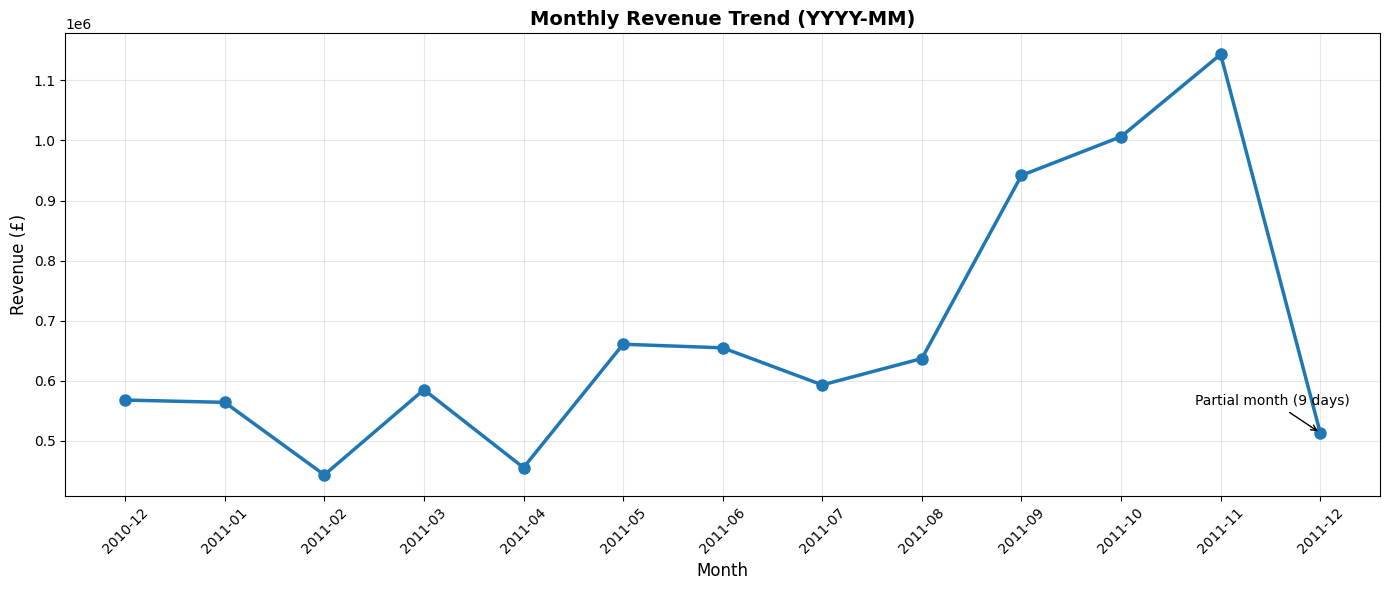


→ Creating Hourly Purchasing Patterns chart...


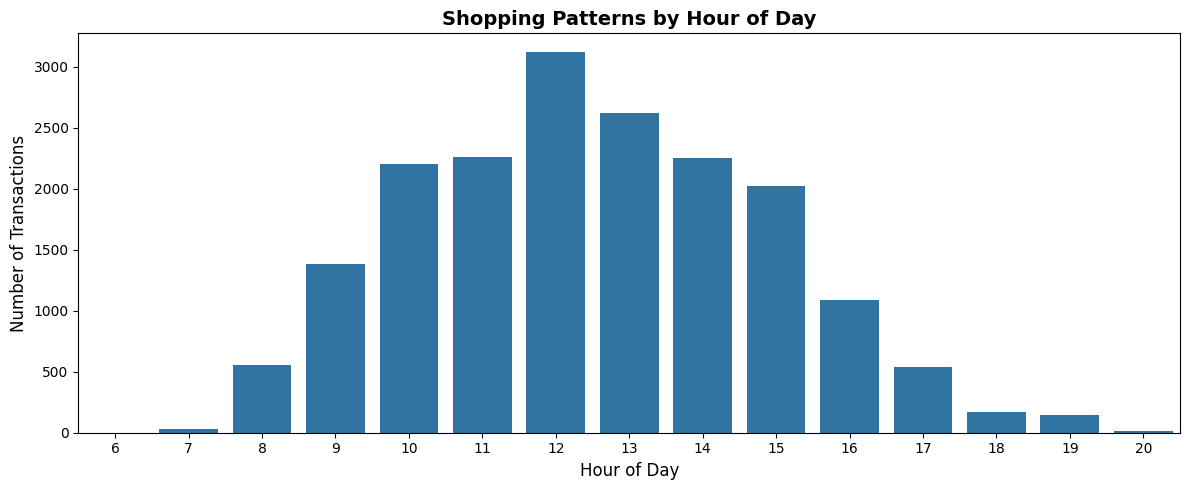


→ Creating Customer Type Over Time chart (NO double-count)...


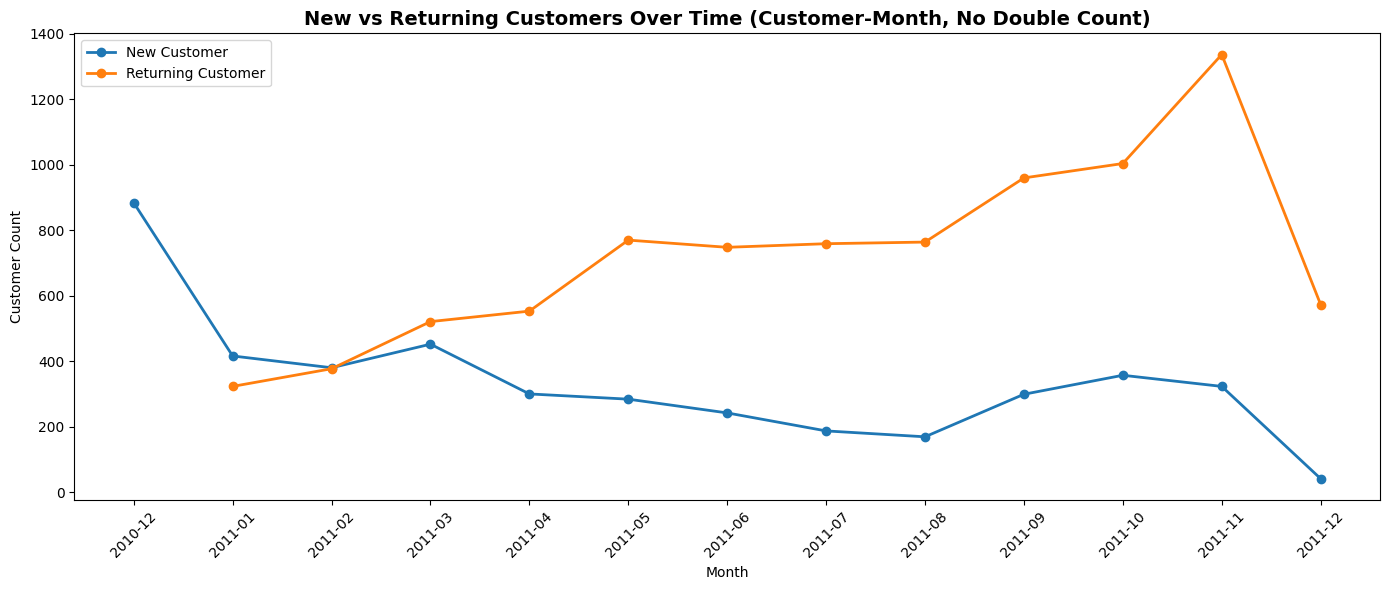

In [14]:
print("\n" + "—" * 60)
print("[STEP 10] EXPLORATORY VISUALIZATIONS")
print("—" * 60)

# 10.1 Monthly Revenue Trend
# 10.1 Monthly Revenue Trend (YYYY-MM, handles partial month)
print("\n→ Creating Monthly Revenue Trend chart...")

monthly = df.groupby(df["InvoiceDate"].dt.to_period("M")).agg(
    Revenue=("Revenue", "sum"),
    Orders=("InvoiceNo", "nunique"),
    Customers=("CustomerID", "nunique"),
    FirstDate=("InvoiceDate", "min"),
    LastDate=("InvoiceDate", "max"),
)

monthly["DaysCovered"] = (monthly["LastDate"] - monthly["FirstDate"]).dt.days + 1
monthly.index = monthly.index.astype(str)  # YYYY-MM

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(monthly.index, monthly["Revenue"].values, marker="o", linewidth=2.5, markersize=8)

ax.set_title("Monthly Revenue Trend (YYYY-MM)", fontsize=14, fontweight="bold")
ax.set_ylabel("Revenue (£)", fontsize=12)
ax.set_xlabel("Month", fontsize=12)
ax.grid(alpha=0.3)
plt.xticks(rotation=45)

# Annotate partial last month (common cause of end drop)
last_m = monthly.index[-1]
ax.annotate(
    f"Partial month ({int(monthly.loc[last_m, 'DaysCovered'])} days)",
    xy=(len(monthly) - 1, monthly["Revenue"].iloc[-1]),
    xytext=(-90, 20),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->")
)

plt.tight_layout()
plt.show()


# 10.4 Hourly Purchasing Patterns
print("\n→ Creating Hourly Purchasing Patterns chart...")
hourly_sales = df.groupby(df["InvoiceDate"].dt.hour)["InvoiceNo"].nunique()

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(x=hourly_sales.index, y=hourly_sales.values, ax=ax)
ax.set_title("Shopping Patterns by Hour of Day", fontsize=14, fontweight="bold")
ax.set_xlabel("Hour of Day", fontsize=12)
ax.set_ylabel("Number of Transactions", fontsize=12)
plt.tight_layout()
plt.show()

# 10.5 Customer Type Over Time
print("\n→ Creating Customer Type Over Time chart (NO double-count)...")

# One row per Customer per Month
cust_month = df.drop_duplicates(["YearMonth", "CustomerID"])[["YearMonth", "CustomerID"]].copy()

# First purchase month per customer
first_month = df.groupby("CustomerID")["YearMonth"].min()

cust_month["CustomerType_Month"] = np.where(
    cust_month["YearMonth"] == cust_month["CustomerID"].map(first_month),
    "New Customer",
    "Returning Customer"
)

cust_counts = (
    cust_month.groupby(["YearMonth", "CustomerType_Month"])["CustomerID"]
    .nunique()
    .reset_index(name="CustomerCount")
)
cust_counts["YearMonth_str"] = cust_counts["YearMonth"].astype(str)

# Optional correctness assertion (should never fail now)
monthly_sum = cust_counts.groupby("YearMonth")["CustomerCount"].sum()
true_unique = df.groupby("YearMonth")["CustomerID"].nunique()
assert (monthly_sum <= true_unique).all(), "Double-count still happening!"

# Plot
fig, ax = plt.subplots(figsize=(14, 6))
for ctype in ["New Customer", "Returning Customer"]:
    data = cust_counts[cust_counts["CustomerType_Month"] == ctype]
    ax.plot(data["YearMonth_str"], data["CustomerCount"], marker="o", linewidth=2, label=ctype)

ax.set_title("New vs Returning Customers Over Time (Customer-Month, No Double Count)", fontsize=14, fontweight="bold")
ax.set_ylabel("Customer Count")
ax.set_xlabel("Month")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# SECTION 11: SEGMENT VISUALIZATIONS
# ------------------------------------------------------------


→ Creating Segment Counts chart...


/var/folders/s9/prg77n3j6zl11m7ghqtc1rf00000gn/T/ipykernel_5806/1945998605.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=segment_counts.values, y=segment_counts.index, ax=ax, palette="Set2")


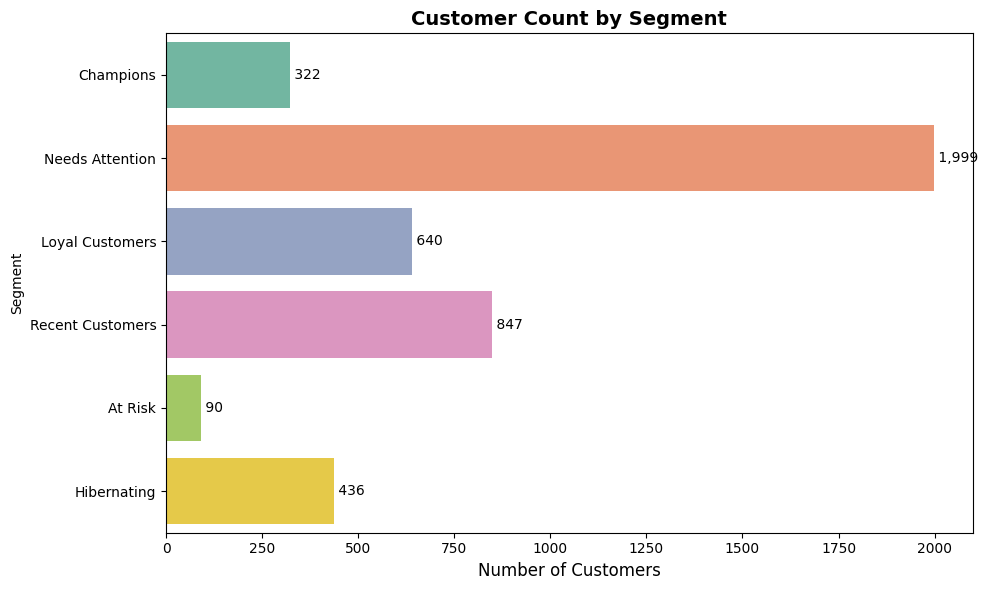


→ Creating Segment Revenue Contribution chart...


/var/folders/s9/prg77n3j6zl11m7ghqtc1rf00000gn/T/ipykernel_5806/1945998605.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=seg_rev.values, y=seg_rev.index, ax=ax, palette="Blues_r")


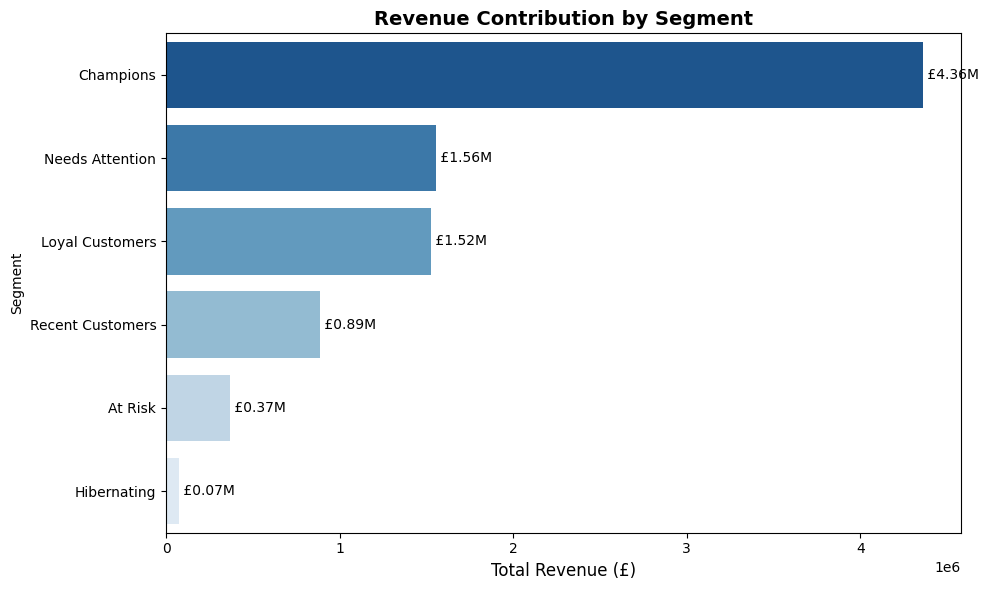


→ Creating R, F, M distributions chart...


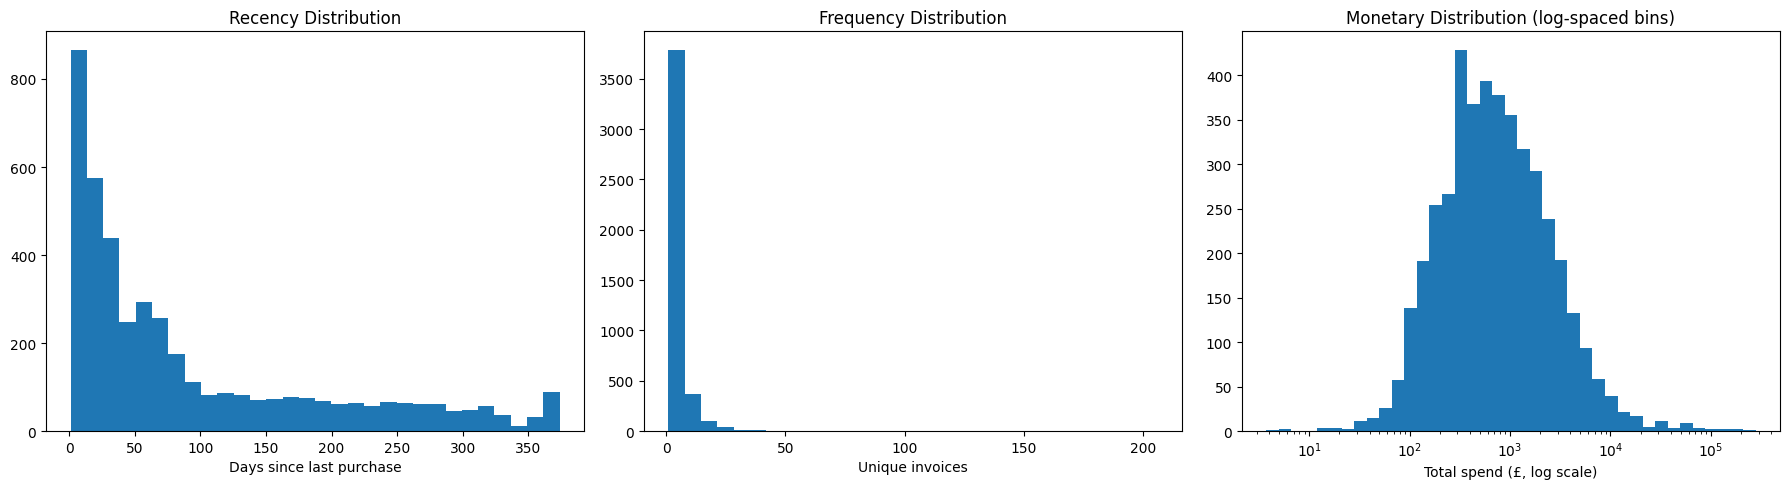


→ Creating Frequency vs Monetary scatter plot...


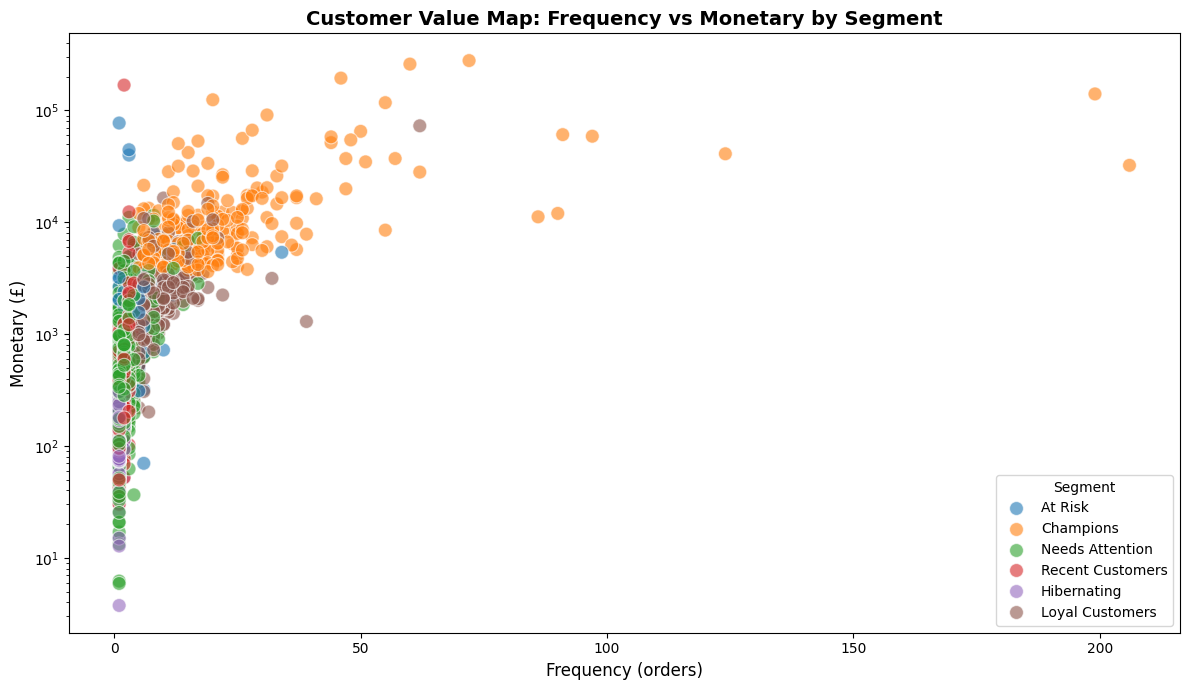

In [15]:
# 11.1 Segment Counts
print("\n→ Creating Segment Counts chart...")
fig, ax = plt.subplots(figsize=(10, 6))

segment_counts = rfm["Segment"].value_counts()
order = segment_summary.index  # order by revenue
segment_counts = segment_counts.reindex(order)

sns.barplot(x=segment_counts.values, y=segment_counts.index, ax=ax, palette="Set2")

ax.set_title("Customer Count by Segment", fontsize=14, fontweight="bold")
ax.set_xlabel("Number of Customers", fontsize=12)

for i, v in enumerate(segment_counts.values):
    ax.text(v, i, f" {v:,}", va="center", fontsize=10)

plt.tight_layout()
plt.show()

# 11.2 Segment Revenue Contribution
print("\n→ Creating Segment Revenue Contribution chart...")
fig, ax = plt.subplots(figsize=(10, 6))

seg_rev = segment_summary["Total_Monetary"].sort_values(ascending=False)
sns.barplot(x=seg_rev.values, y=seg_rev.index, ax=ax, palette="Blues_r")
ax.set_title("Revenue Contribution by Segment", fontsize=14, fontweight="bold")
ax.set_xlabel("Total Revenue (£)", fontsize=12)

for i, v in enumerate(seg_rev.values):
    ax.text(v, i, f" £{v/1_000_000:.2f}M", va="center", fontsize=10)

plt.tight_layout()
plt.show()

# 11.3 R, F, M Distributions
print("\n→ Creating R, F, M distributions chart...")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(rfm["Recency"], bins=30)
axes[0].set_title("Recency Distribution")
axes[0].set_xlabel("Days since last purchase")

axes[1].hist(rfm["Frequency"], bins=30)
axes[1].set_title("Frequency Distribution")
axes[1].set_xlabel("Unique invoices")

m = rfm["Monetary"].dropna()
m = m[m > 0]  # safety

bins = np.logspace(np.log10(m.min()), np.log10(m.max()), 40)

axes[2].hist(m, bins=bins)
axes[2].set_xscale("log")
axes[2].set_title("Monetary Distribution (log-spaced bins)")
axes[2].set_xlabel("Total spend (£, log scale)")


plt.tight_layout()
plt.show()


# 11.4 Frequency vs Monetary by Segment
print("\n→ Creating Frequency vs Monetary scatter plot...")
fig, ax = plt.subplots(figsize=((12, 7)))

sns.scatterplot(data=rfm, x="Frequency", y="Monetary", hue="Segment", alpha=0.6, s=100, ax=ax)
ax.set_title("Customer Value Map: Frequency vs Monetary by Segment", fontsize=14, fontweight="bold")
ax.set_xlabel("Frequency (orders)", fontsize=12)
ax.set_ylabel("Monetary (£)", fontsize=12)
ax.set_yscale("log")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# SECTION 12: DECILE VISUALIZATIONS
# ------------------------------------------------------------


————————————————————————————————————————————————————————————
[STEP 12] DECILE VISUALIZATIONS
————————————————————————————————————————————————————————————

→ Creating Revenue by Decile chart...


/var/folders/s9/prg77n3j6zl11m7ghqtc1rf00000gn/T/ipykernel_5806/2864584263.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/s9/prg77n3j6zl11m7ghqtc1rf00000gn/T/ipykernel_5806/2864584263.py:12: UserWarning: Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14
  sns.barplot(


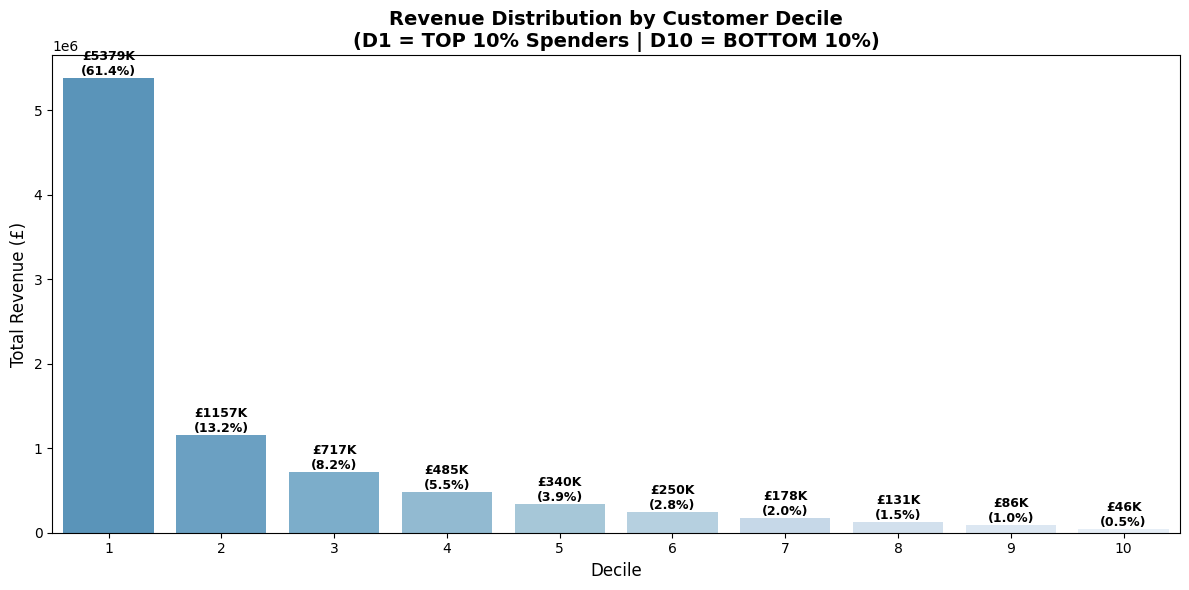


→ Creating Cumulative Revenue chart...


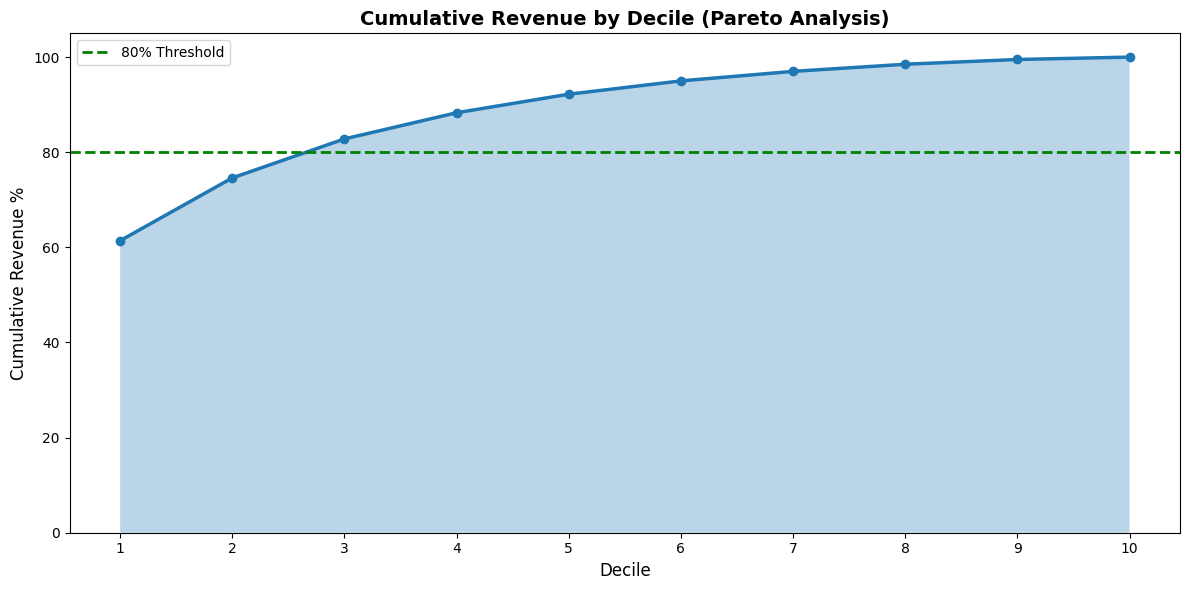

In [16]:
print("\n" + "—" * 60)
print("[STEP 12] DECILE VISUALIZATIONS")
print("—" * 60)

# 12.1 Revenue by Decile
print("\n→ Creating Revenue by Decile chart...")
fig, ax = plt.subplots(figsize=(12, 6))

deciles_sorted = deciles.sort_index(ascending=True)  # D1 first (highest spenders)
colors = plt.cm.Blues_r(np.linspace(0.4, 0.9, len(deciles_sorted)))

sns.barplot(
    x=deciles_sorted.index,
    y=deciles_sorted["TotalRevenue"],
    ax=ax,
    palette=colors
)

ax.set_title(
    "Revenue Distribution by Customer Decile\n(D1 = TOP 10% Spenders | D10 = BOTTOM 10%)",
    fontsize=14,
    fontweight="bold",
)
ax.set_xlabel("Decile", fontsize=12)
ax.set_ylabel("Total Revenue (£)", fontsize=12)

# Add value labels on bars
for i, (idx, row) in enumerate(deciles_sorted.iterrows()):
    ax.text(
        i,
        row["TotalRevenue"],
        f"£{row['TotalRevenue']/1000:.0f}K\n({row['Revenue_%']:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold",
    )

plt.tight_layout()
plt.show()

# 12.2 Cumulative Revenue by Decile (Pareto)
print("\n→ Creating Cumulative Revenue chart...")
fig, ax = plt.subplots(figsize=(12, 6))

deciles_sorted = deciles.sort_index(ascending=True)  
x = deciles_sorted.index.to_numpy()
y = deciles_sorted["CumRevenue_%"].to_numpy(dtype=float)

ax.plot(x, y, marker="o", linewidth=2.5)
ax.fill_between(x, y, alpha=0.3)

ax.set_xticks(x)
ax.set_xticklabels(deciles_sorted.index.to_list())


ax.axhline(80, color="green", linestyle="--", linewidth=2, label="80% Threshold")
ax.set_title("Cumulative Revenue by Decile (Pareto Analysis)", fontsize=14, fontweight="bold")
ax.set_xlabel("Decile", fontsize=12)
ax.set_ylabel("Cumulative Revenue %", fontsize=12)
ax.set_ylim(0, 105)
ax.legend()

plt.tight_layout()
plt.show()

In [17]:
# ------------------------------------------------------------
# [STEP 13] BUDGET ALLOCATION FRAMEWORK
# ------------------------------------------------------------
#13.1
print("\n" + "—" * 60)
print("[STEP 13] BUDGET ALLOCATION FRAMEWORK")
print("—" * 60)

budget_alloc = deciles[["Revenue_%"]].copy()
budget_alloc.rename(columns={"Revenue_%": "Revenue_%"}, inplace=True)

# In screenshot: Budget_% equals Revenue_%
budget_alloc["Budget_%"] = budget_alloc["Revenue_%"]

print("\nSuggested Marketing Budget Allocation by Decile:")
print(budget_alloc.round(1))


————————————————————————————————————————————————————————————
[STEP 13] BUDGET ALLOCATION FRAMEWORK
————————————————————————————————————————————————————————————

Suggested Marketing Budget Allocation by Decile:
        Revenue_%  Budget_%
Decile                     
1            61.4      61.4
2            13.2      13.2
3             8.2       8.2
4             5.5       5.5
5             3.9       3.9
6             2.8       2.8
7             2.0       2.0
8             1.5       1.5
9             1.0       1.0
10            0.5       0.5


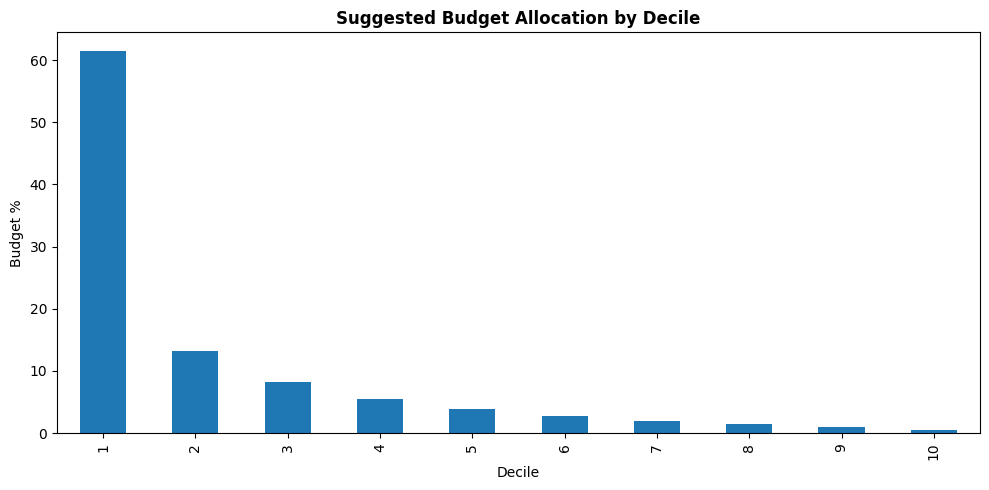

In [18]:
#13.2
if plt is not None:
    fig, ax = plt.subplots(figsize=(10, 5))
    budget_alloc["Budget_%"].plot(kind="bar", ax=ax)
    ax.set_title("Suggested Budget Allocation by Decile", fontweight="bold")
    ax.set_xlabel("Decile")
    ax.set_ylabel("Budget %")
    plt.tight_layout()
    plt.show()